In [6]:
from itertools import groupby
from statistics import correlation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df= pd.read_excel(r'C:\Users\DELL LS\Downloads\البروجيكت\Cleaned_FAANG_Data 1.xlsx')
df.head()

,Source.Name,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Change(%),Range
0,Amazon.csv,1997-05-15,2.437500,2.500000,1.927083,1.958333,1.958333,72156000,1997,5,-0.196581,0.572917
1,Amazon.csv,1997-05-16,1.968750,1.979167,1.708333,1.729167,1.729167,14700000,1997,5,-0.121693,0.270834
2,Amazon.csv,1997-05-19,1.760417,1.770833,1.625000,1.708333,1.708333,6106800,1997,5,-0.029586,0.145833
3,Amazon.csv,1997-05-20,1.729167,1.750000,1.635417,1.635417,1.635417,5467200,1997,5,-0.054217,0.114583
4,Amazon.csv,1997-05-21,1.635417,1.645833,1.375000,1.427083,1.427083,18853200,1997,5,-0.127389,0.270833


In [8]:
df.shape

(26565, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26565 entries, 0 to 26564
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Source.Name  26565 non-null  object        
 1   Date         26565 non-null  datetime64[ns]
 2   Open         26565 non-null  float64       
 3   High         26565 non-null  float64       
 4   Low          26565 non-null  float64       
 5   Close        26565 non-null  float64       
 6   Adj Close    26565 non-null  float64       
 7   Volume       26565 non-null  int64         
 8   Year         26565 non-null  int64         
 9   Month        26565 non-null  int64         
 10  Change(%)    26565 non-null  float64       
 11  Range        26565 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(3), object(1)
memory usage: 2.4+ MB


In [10]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Change(%),Range
count,26565,26565.000000,26565.000000,26565.000000,26565.000000,26565.000000,2.656500e+04,26565.000000,26565.000000,26565.000000,26565.000000
mean,2007-06-23 10:20:49.734612992,190.406730,192.465780,188.206288,190.428805,190.224947,1.369710e+08,2006.975118,6.531677,0.000389,4.259493
min,1980-12-12 00:00:00,0.049665,0.049665,0.049107,0.049107,0.038743,2.856000e+05,1980.000000,1.000000,-0.243524,0.000000
25%,2002-04-30 00:00:00,1.658571,1.700000,1.628571,1.657143,1.628571,6.040800e+06,2002.000000,4.000000,-0.011111,0.060715
50%,2009-07-07 00:00:00,33.615002,34.279999,33.080002,33.754284,33.490002,1.856200e+07,2009.000000,7.000000,0.000000,0.890001
75%,2015-05-13 00:00:00,193.059998,195.300003,190.545547,193.149994,193.149994,1.615040e+08,2015.000000,9.000000,0.011207,4.390015
max,2020-09-04 00:00:00,3251.060059,3344.290039,3165.429932,3225.000000,3225.000000,7.421641e+09,2020.000000,12.000000,0.340266,275.900146
std,NaN,379.619521,383.523704,375.382955,379.673774,379.764606,2.640676e+08,9.933866,3.415172,0.025278,10.002730


In [11]:
df.isnull().sum()

Source.Name    0
Date           0
Open           0
High           0
Low            0
Close          0
Adj Close      0
Volume         0
Year           0
Month          0
Change(%)      0
Range          0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df = df.sort_values(['Source.Name', 'Date'])
df['Source.Name'].unique
df['Source.Name'].value_counts()


Source.Name
Apple.csv       10015
Amazon.csv       5852
Netflix.csv      4581
Google.csv       4041
Facebook.csv     2076
Name: count, dtype: int64

In [14]:
Company_stats = df.groupby('Source.Name')['Adj Close'].agg(['mean', 'median', 'std', 'min', 'max'])
print(Company_stats.round(3))
df['Daily_Return'] = df.groupby('Source.Name')['Adj Close'].pct_change()
print(df[['Source.Name', 'Date', 'Adj Close', 'Daily_Return']].head(10))
Return_Stats = df.groupby('Source.Name')['Daily_Return'].agg(['mean', 'std', 'min', 'max'])
print(Return_Stats.round(3))

                 mean   median      std     min      max
Source.Name                                             
Amazon.csv    377.501   83.603  596.287   1.396  3225.00
Apple.csv       8.478    0.369   16.466   0.039   134.18
Facebook.csv  117.410  117.765   61.595  17.730   268.44
Google.csv    533.999  342.177  383.326  50.055  1717.39
Netflix.csv    78.072   15.324  118.435   0.373   548.73
  Source.Name       Date  Adj Close  Daily_Return
0  Amazon.csv 1997-05-15   1.958333           NaN
1  Amazon.csv 1997-05-16   1.729167     -0.117021
2  Amazon.csv 1997-05-19   1.708333     -0.012049
3  Amazon.csv 1997-05-20   1.635417     -0.042683
4  Amazon.csv 1997-05-21   1.427083     -0.127389
5  Amazon.csv 1997-05-22   1.395833     -0.021898
6  Amazon.csv 1997-05-23   1.500000      0.074627
7  Amazon.csv 1997-05-27   1.583333      0.055555
8  Amazon.csv 1997-05-28   1.531250     -0.032895
9  Amazon.csv 1997-05-29   1.505208     -0.017007
               mean    std    min    max
Source.Nam

In [15]:
Performance = df.groupby('Source.Name').agg(
    First_Price = ('Adj Close', 'first'),
    Last_Price = ('Adj Close', 'last'),
)
Performance['Total Return'] = ((Performance['Last_Price'] - Performance['First_Price'])/Performance['First_Price'])*100
print(Performance.round(2))

              First_Price  Last_Price  Total Return
Source.Name                                        
Amazon.csv           1.96     3148.02     160649.99
Apple.csv            0.10      134.18     132409.05
Facebook.csv        38.23      262.34        586.22
Google.csv          50.22     1581.21       3048.55
Netflix.csv          1.20      498.62      41575.69


In [16]:
df['SMA 50'] = df.groupby('Source.Name')['Adj Close'].transform(lambda x: x.rolling(50).mean())
df['SMA 200'] = df.groupby('Source.Name')['Adj Close'].transform(lambda x: x.rolling(200).mean())
print(df[['Source.Name', 'Adj Close', 'SMA 50', 'SMA 200']].tail(10))

       Source.Name   Adj Close      SMA 50    SMA 200
26555  Netflix.csv  490.100006  456.885002  370.06240
26556  Netflix.csv  489.820007  457.871002  371.14755
26557  Netflix.csv  477.579987  458.786202  372.16315
26558  Netflix.csv  480.450012  459.629802  373.21180
26559  Netflix.csv  495.649994  460.703802  374.35240
26560  Netflix.csv  488.510010  461.390202  375.39255
26561  Netflix.csv  484.480011  462.028203  376.40030
26562  Netflix.csv  485.799988  462.723402  377.40165
26563  Netflix.csv  488.880005  463.547602  378.42480
26564  Netflix.csv  498.619995  464.795002  379.48650


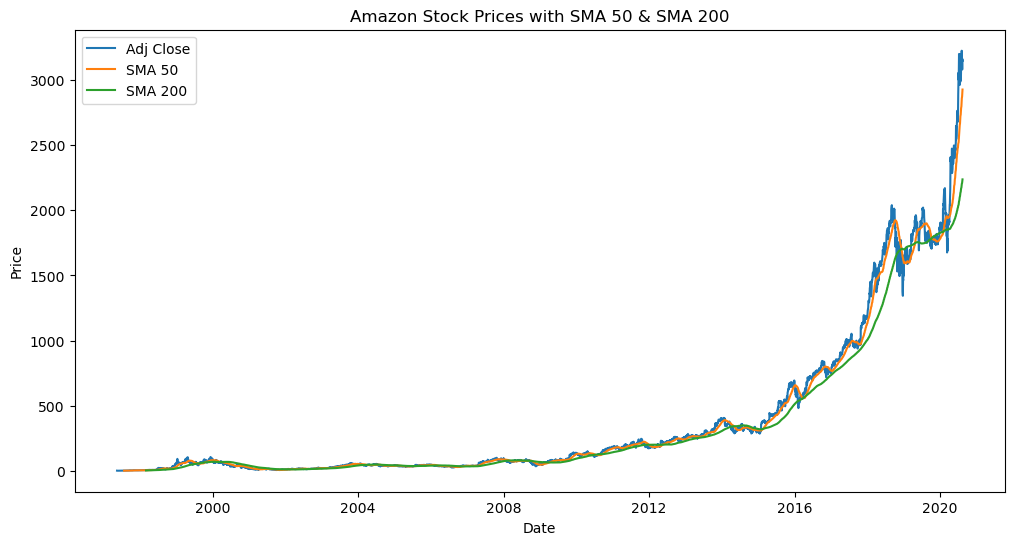

In [17]:
amazon = df[df['Source.Name'] == 'Amazon.csv']
plt.figure(figsize = (12,6))
plt.plot(amazon['Date'], amazon['Adj Close'], label = 'Adj Close')
plt.plot(amazon['Date'], amazon['SMA 50'], label = 'SMA 50')
plt.plot(amazon['Date'], amazon['SMA 200'], label = 'SMA 200')
plt.title('Amazon Stock Prices with SMA 50 & SMA 200')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

Source.Name   Amazon.csv  Apple.csv  Facebook.csv  Google.csv  Netflix.csv
Source.Name                                                               
Amazon.csv         1.000      0.305         0.435       0.482        0.336
Apple.csv          0.305      1.000         0.381       0.496        0.251
Facebook.csv       0.435      0.381         1.000       0.486        0.274
Google.csv         0.482      0.496         0.486       1.000        0.269
Netflix.csv        0.336      0.251         0.274       0.269        1.000


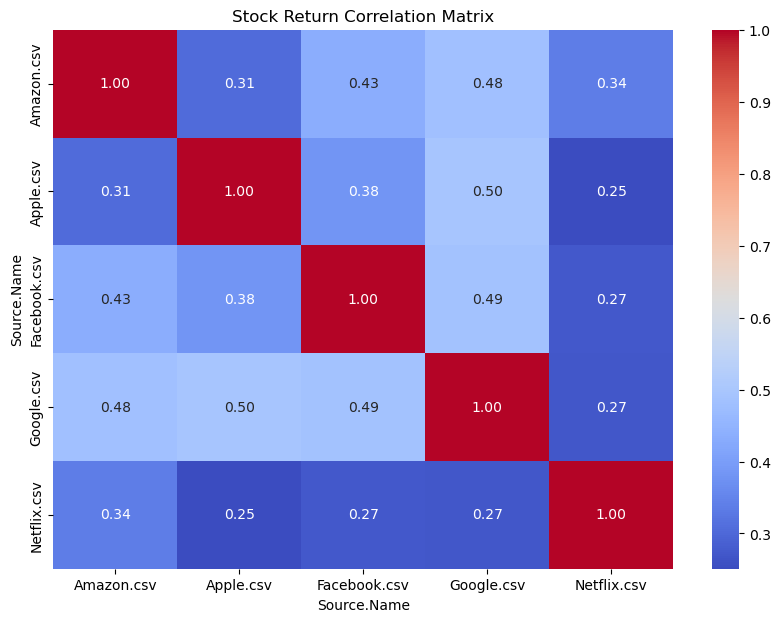

In [18]:
returns = df.pivot(index='Date', columns='Source.Name', values='Daily_Return')
corr_matrix = returns.corr()
print(corr_matrix.round(3))
plt.figure(figsize = (10,7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt = '.2f')
plt.title('Stock Return Correlation Matrix')
plt.show()

In [19]:
Volatility = df.groupby('Source.Name')['Daily_Return'].std()
print(Volatility.sort_values(ascending=False).round(3))

Source.Name
Amazon.csv      0.037
Netflix.csv     0.036
Apple.csv       0.029
Facebook.csv    0.024
Google.csv      0.019
Name: Daily_Return, dtype: float64


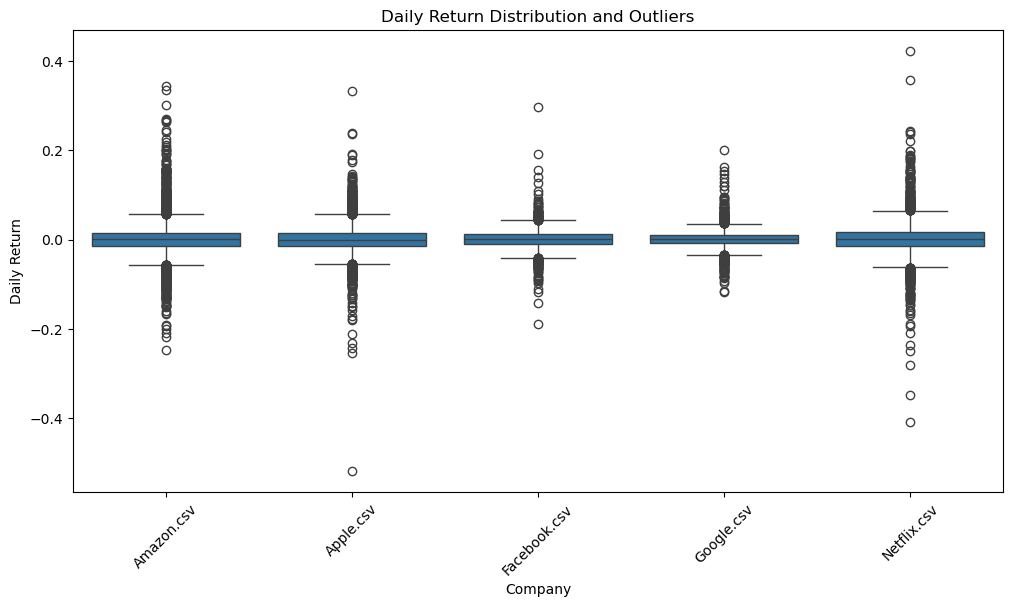

In [21]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Source.Name',
    y='Daily_Return'
)

plt.title('Daily Return Distribution and Outliers')
plt.xlabel('Company')
plt.ylabel('Daily Return')

plt.xticks(rotation=45)
plt.show()

In [22]:
Q1 = df.groupby('Source.Name')['Daily_Return'].transform(
    lambda x: x.quantile(0.25)
)

Q3 = df.groupby('Source.Name')['Daily_Return'].transform(
    lambda x: x.quantile(0.75)
)

IQR = Q3 - Q1

outliers = (df['Daily_Return'] < Q1 - 1.5 * IQR) | (
    df['Daily_Return'] > Q3 + 1.5 * IQR
)

print(df.loc[outliers, 'Source.Name'].value_counts())

Source.Name
Apple.csv       542
Amazon.csv      537
Netflix.csv     264
Google.csv      245
Facebook.csv    127
Name: count, dtype: int64


In [23]:
print(
    df.loc[outliers, 
           ['Source.Name', 'Date', 'Adj Close', 'Daily_Return']]
    .sort_values('Daily_Return')
    .head(10)
)

print(
    df.loc[outliers, 
           ['Source.Name', 'Date', 'Adj Close', 'Daily_Return']]
    .sort_values('Daily_Return', ascending=False)
    .head(10)
)

       Source.Name       Date  Adj Close  Daily_Return
10855    Apple.csv 2000-09-29   0.397350     -0.518691
22588  Netflix.csv 2004-10-15   1.471429     -0.409065
24358  Netflix.csv 2011-10-25  11.052857     -0.348957
22524  Netflix.csv 2004-07-16   3.288571     -0.280625
6554     Apple.csv 1983-09-23   0.085412     -0.253842
24546  Netflix.csv 2012-07-25   8.611428     -0.250155
1056    Amazon.csv 2001-07-24  12.060000     -0.247661
7582     Apple.csv 1987-10-19   0.257845     -0.243521
23472  Netflix.csv 2008-04-22   4.285714     -0.237030
9034     Apple.csv 1993-07-16   0.205230     -0.230772
        Source.Name       Date   Adj Close  Daily_Return
24670   Netflix.csv 2013-01-24   20.980000      0.422235
22081   Netflix.csv 2002-10-10    0.506429      0.358239
1139     Amazon.csv 2001-11-26   12.210000      0.344714
983      Amazon.csv 2001-04-09   11.180000      0.335723
10060     Apple.csv 1997-08-06    0.203015      0.332277
1132     Amazon.csv 2001-11-14    9.490000      0.301

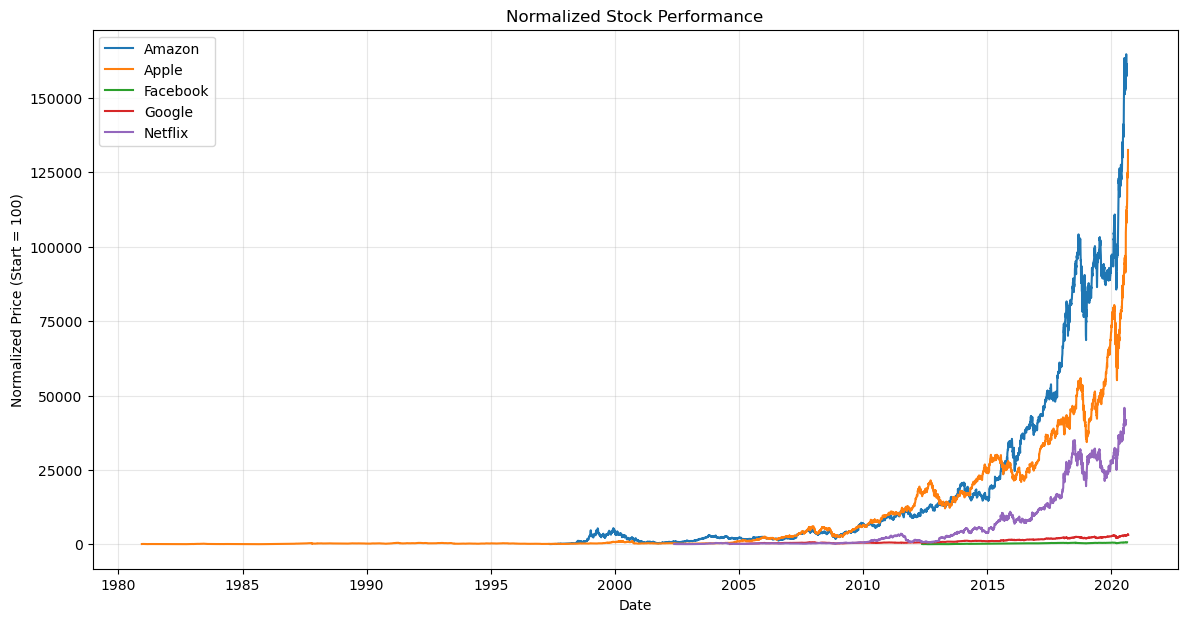

In [24]:
df['Normalized_Price'] = df.groupby('Source.Name')['Adj Close'].transform(
    lambda x: (x / x.iloc[0]) * 100
)

plt.figure(figsize=(14, 7))

for company in df['Source.Name'].unique():
    company_data = df[df['Source.Name'] == company]
    
    plt.plot(
        company_data['Date'],
        company_data['Normalized_Price'],
        label=company.replace('.csv', '')
    )

plt.title('Normalized Stock Performance')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Start = 100)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [25]:
df['Running_Max'] = df.groupby('Source.Name')['Adj Close'].cummax()

df['Drawdown'] = (
    (df['Adj Close'] - df['Running_Max'])
    / df['Running_Max']
)

Max_Drawdown = df.groupby('Source.Name')['Drawdown'].min()

print(Max_Drawdown.sort_values().round(4))

Source.Name
Amazon.csv     -0.9440
Netflix.csv    -0.8199
Apple.csv      -0.8180
Google.csv     -0.6529
Facebook.csv   -0.5362
Name: Drawdown, dtype: float64


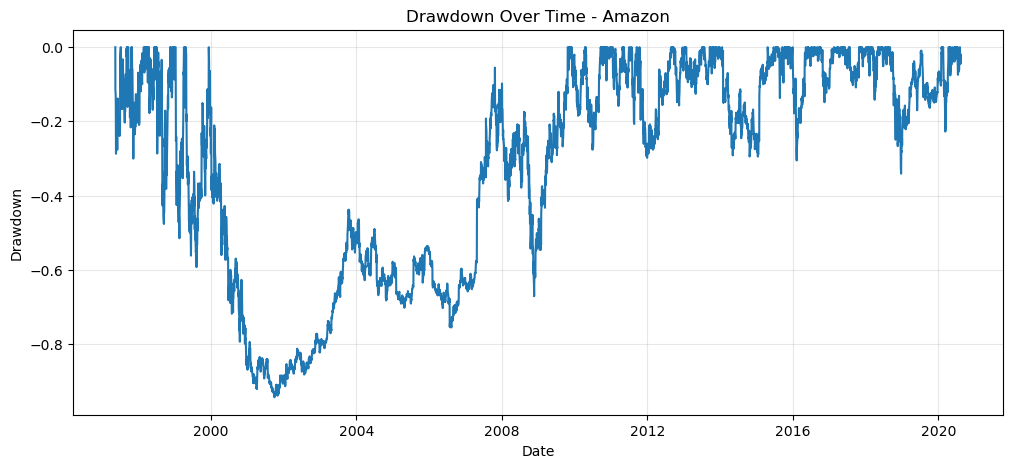

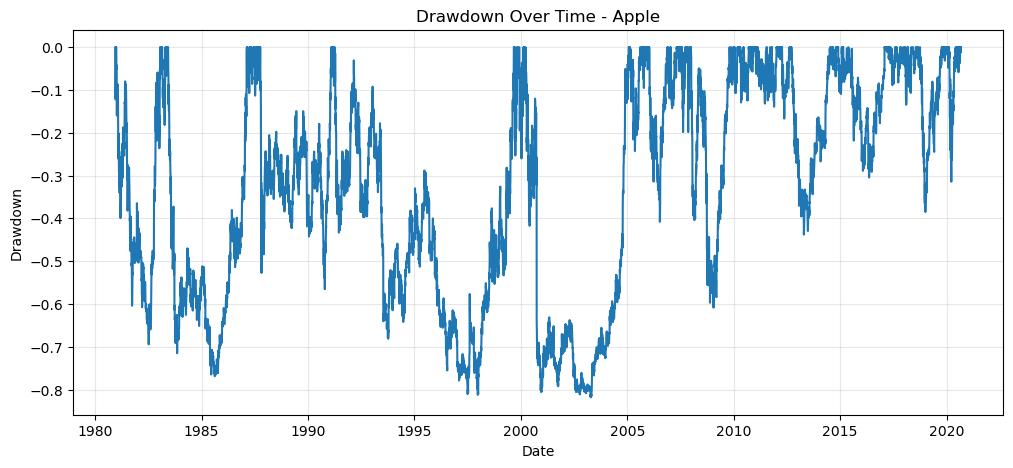

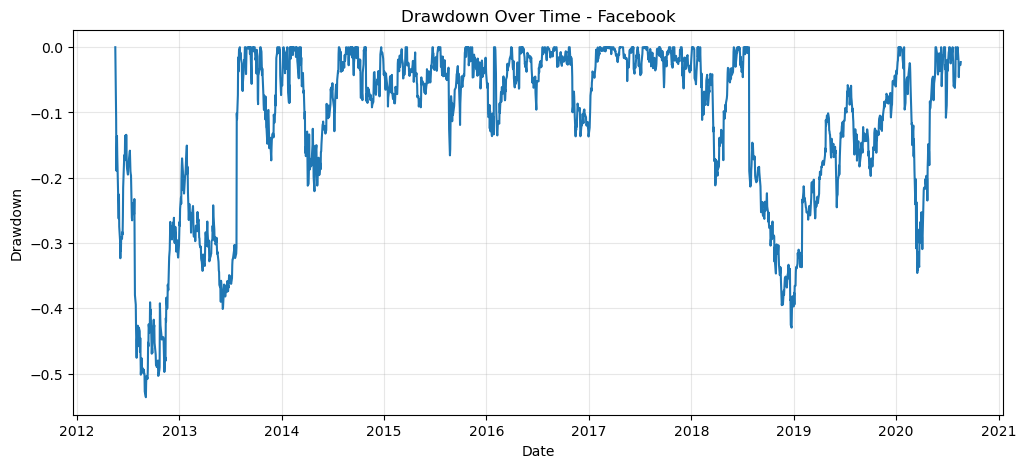

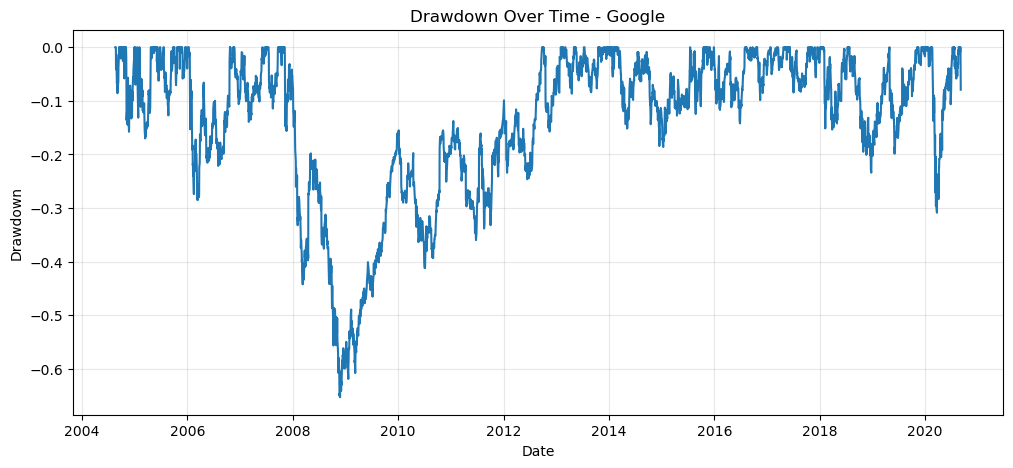

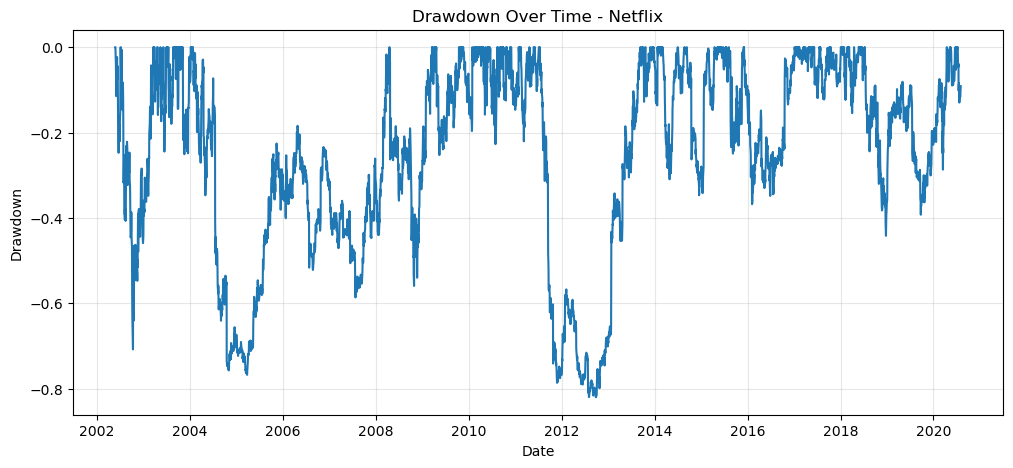

In [27]:
companies = df['Source.Name'].unique()

for company in companies:
    company_data = df[df['Source.Name'] == company]

    plt.figure(figsize=(12, 5))

    plt.plot(
        company_data['Date'],
        company_data['Drawdown']
    )

    plt.title(f'Drawdown Over Time - {company.replace(".csv", "")}')
    plt.xlabel('Date')
    plt.ylabel('Drawdown')

    plt.grid(alpha=0.3)
    plt.show()

In [20]:
Summary = df.groupby('Source.Name').agg(
    Avg_Price=('Adj Close', 'mean'),
    Price_Std=('Adj Close', 'std'),
    Min_Price=('Adj Close', 'min'),
    Max_Price=('Adj Close', 'max'),
    Avg_Return=('Daily_Return', 'mean'),
    Return_Volatility=('Daily_Return', 'std')
)
print(Summary.round(4))

              Avg_Price  Price_Std  Min_Price  Max_Price  Avg_Return  \
Source.Name                                                            
Amazon.csv     377.5007   596.2875     1.3958    3225.00      0.0019   
Apple.csv        8.4782    16.4662     0.0387     134.18      0.0011   
Facebook.csv   117.4104    61.5951    17.7300     268.44      0.0012   
Google.csv     533.9991   383.3260    50.0551    1717.39      0.0010   
Netflix.csv     78.0721   118.4353     0.3729     548.73      0.0020   

              Return_Volatility  
Source.Name                      
Amazon.csv               0.0372  
Apple.csv                0.0287  
Facebook.csv             0.0235  
Google.csv               0.0193  
Netflix.csv              0.0363  


# Executive Summary: FAANG Stocks EDA & Performance Analysis

## 📊 Overview
This Exploratory Data Analysis (EDA) focuses on analyzing historical stock prices, daily returns, volatility, moving averages, and cross-asset correlations for the **FAANG** tech giants (*Meta, Amazon, Apple, Netflix, Google*).

---

## 🔑 Key Insights & Findings

### 1. Cumulative Performance & Historical Returns
* **Top Performers:** **Amazon (AMZN)** achieved the highest cumulative total return historically (+160,649%), followed by **Apple (AAPL)** (+132,409%).
* **Daily Growth Rate:** **Netflix (NFLX)** and **Amazon (AMZN)** lead in average daily returns (~0.20% per day).

### 2. Risk & Volatility Assessment
* **Highest Volatility:** **Amazon** (Std: 3.72%) and **Netflix** (Std: 3.63%) exhibit the highest daily price swings and risk profiles.
* **Lowest Volatility:** **Google (GOOGL)** stands out as the most stable and least volatile stock among FAANG, with a daily return standard deviation of **1.93%**.

### 3. Correlation & Diversification Analysis
* **Strong Relationships:** A moderate-to-strong positive correlation exists between **Google & Apple** ($r = 0.50$) and **Google & Amazon** ($r = 0.48$).
* **Diversification Asset:** **Netflix** exhibits the lowest correlation with the rest of the FAANG basket ($r < 0.34$), making it an ideal candidate for portfolio risk diversification.

---

## 🛠️ Next Steps for BI Dashboarding
1. **Interactive Metrics:** Build KPI cards for *Cumulative Return*, *Average Volatility*, and *Current SMA 50/200 Trend*.
2. **Interactive Visualizations:** Implement dynamic time-series charts for SMA crossovers (*Golden Cross / Death Cross*) and interactive Correlation Heatmaps.